# Binary parity and the fee curve

A binary event contract has an arithmetic identity: YES and NO settle to
exactly 1.00 between them. When both offers sum to less than 1.00 you can buy
the pair and hold a locked-in gain. This recipe measures that basis across a
panel of markets, then shows why most of it is unreachable: prediction-market
fees scale with `p*(1-p)`, so the same two-cent basis is a trade at 5 cents and
a loss at 50 cents. The backtest runs the same signals twice, once gross and
once with the venue's real curve, and the gross result is checked against the
arithmetic by hand.

In [1]:
import datetime as dt

import matplotlib.pyplot as plt

import cookbook_utils as cu
import h5i_db
from h5i_db import backtest, col

db = h5i_db.Database(cu.fresh_db("05_binary_parity_and_fee_curves"), create=True)

## The panel

`cu.make_prediction_markets` returns the four canonical backtest tables for a
panel of binary markets. Quotes carry a deliberate favorite-longshot bias and
the NO book is the complement of the YES book plus a small oscillating basis,
so pair costs cross 1.00 in both directions during the session.

`book_deltas` is the input this recipe reads. One row is one price level of one
atomic book event; rows sharing an `event_index` are one snapshot and the last
carries `is_last=True`.

| column | type | meaning |
|---|---|---|
| `ts_init` | `timestamp[ns]` | when the event reached the recorder; replay sorts by this |
| `ts_event` | `timestamp[ns]` | when the venue says it happened |
| `instrument_id` | `string` | the market |
| `outcome` | `uint16` | 0 = YES, 1 = NO |
| `action` | `string` | `snapshot` here; deltas and gaps also exist |
| `side` | `string` | `buy` is the bid side, `sell` the ask side |
| `price` | `float64` | probability, on a 0.001 tick grid |
| `size` | `float64` | contracts displayed at that level |
| `event_index` | `int64` | groups rows into one atomic event |
| `is_last` | `bool` | ends the event |

In [2]:
panel = cu.make_prediction_markets(n_markets=120, steps=32, seed=11)
book = panel["book_deltas"]
print(f"{book.num_rows:,} rows x {book.num_columns} columns")
book.to_pandas().head()

17,280 rows x 11 columns


,ts_init,ts_event,instrument_id,outcome,action,side,price,size,event_index,is_last,source_vendor
0,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,buy,0.098,89.826,1,False,cookbook-sim
1,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,0,snapshot,sell,0.114,61.859,1,True,cookbook-sim
2,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,buy,0.874,57.380,2,False,cookbook-sim
3,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0000,1,snapshot,sell,0.890,100.910,2,True,cookbook-sim
4,2026-05-01 12:00:00,2026-05-01 12:00:00,EVENT-0001,0,snapshot,buy,0.098,121.779,3,False,cookbook-sim


## Store and pin

Every table is time-indexed on `ts_init`, the column replay sorts by. The
named snapshot is what makes the study re-runnable: the config records the pin,
not "whatever the table held that afternoon".

In [3]:
for name, table in panel.items():
    db.create_table(name, table.schema, time_column="ts_init")
    db.append(name, table, note="panel load")
db.snapshot("panel-v1", tables=list(panel), note="parity study input")
print({name: db.sql(f"SELECT count(*) AS n FROM {name}").to_pandas()["n"][0] for name in panel})

{'instruments': np.int64(240), 'book_deltas': np.int64(17280), 'trades': np.int64(3840), 'resolutions': np.int64(120)}


## The basis

One row per market per instant, with both offers side by side. A buyer of the
pair pays `ask_yes + ask_no` and receives exactly 1.00 at resolution, so
`1 - pair_cost` is the gross edge per contract. The mid is carried along
because the fee depends on the price level, not on the basis.

In [4]:
# Stop at expiry. The panel keeps quoting after the result is observable, and a
# resolved book sits at ~1.00 / ~0.00: not an opportunity, just an answer.
expiry_ns = int(db.sql("SELECT max(expiration_ns) AS e FROM instruments").to_pandas()["e"][0])
quotes = db.sql(
    f"""
    SELECT ts_init AS ts, instrument_id, outcome,
           max(CASE WHEN side = 'buy'  THEN price END) AS bid,
           max(CASE WHEN side = 'sell' THEN price END) AS ask
    FROM h5i('book_deltas', 'panel-v1')
    WHERE ts_init <= to_timestamp_nanos({expiry_ns})
    GROUP BY ts_init, instrument_id, outcome
    """
).to_arrow()
db.create_table("quotes", quotes.schema, time_column="ts")
db.append("quotes", quotes.sort_by([("ts", "ascending")]))

yes = db.table("quotes").filter(col("outcome") == 0)
no = db.table("quotes").filter(col("outcome") == 1)
pairs = (
    yes.join(no, on=["ts", "instrument_id"], how="inner")
    .select(
        ts=col("ts", relation="l"),
        instrument_id=col("instrument_id", relation="l"),
        ask_yes=col("ask", relation="l"),
        ask_no=col("ask", relation="r"),
        mid_yes=(col("bid", relation="l") + col("ask", relation="l")) / 2,
    )
    .with_columns(pair_cost=col("ask_yes") + col("ask_no"))
    .with_columns(gross_edge=1.0 - col("pair_cost"))
    .to_pandas()
)
print(f"{len(pairs):,} market-instants")
print(f"pair cost: min {pairs.pair_cost.min():.4f}  median {pairs.pair_cost.median():.4f}  max {pairs.pair_cost.max():.4f}")
print(f"below 1.00 (gross arbitrage): {(pairs.gross_edge > 0).mean():.1%}")

3,840 market-instants
pair cost: min 0.9730  median 1.0120  max 1.0510
below 1.00 (gross arbitrage): 38.4%


## Why most of it is unreachable

These venues do not charge `notional x rate`. The fee is
`rate * quantity * p * (1 - p)`, which is zero at certainty and peaks at even
odds. Buying a pair pays it on both legs, so the hurdle for the pair is
`rate * (p_yes*(1-p_yes) + p_no*(1-p_no))`. At a 7% rate that is 0.7 cents near
the tails and 3.5 cents at 50/50. A basis is not an opportunity until it clears
its own price level's hurdle.

In [5]:
FEE_RATE = 0.07


def pair_fee(mid_yes: float, rate: float = FEE_RATE) -> float:
    """Kalshi-style quadratic fee for one contract of each leg."""
    mid_no = 1.0 - mid_yes
    return rate * (mid_yes * (1.0 - mid_yes) + mid_no * (1.0 - mid_no))


pairs["fee_hurdle"] = pairs.mid_yes.map(pair_fee)
pairs["net_edge"] = pairs.gross_edge - pairs.fee_hurdle
print(f"clears the hurdle: {(pairs.net_edge > 0).mean():.1%} of market-instants")
for level in (0.05, 0.15, 0.30, 0.50):
    print(f"  hurdle at p={level:.2f}: {pair_fee(level):.4f}")

clears the hurdle: 2.8% of market-instants
  hurdle at p=0.05: 0.0067
  hurdle at p=0.15: 0.0179
  hurdle at p=0.30: 0.0294
  hurdle at p=0.50: 0.0350


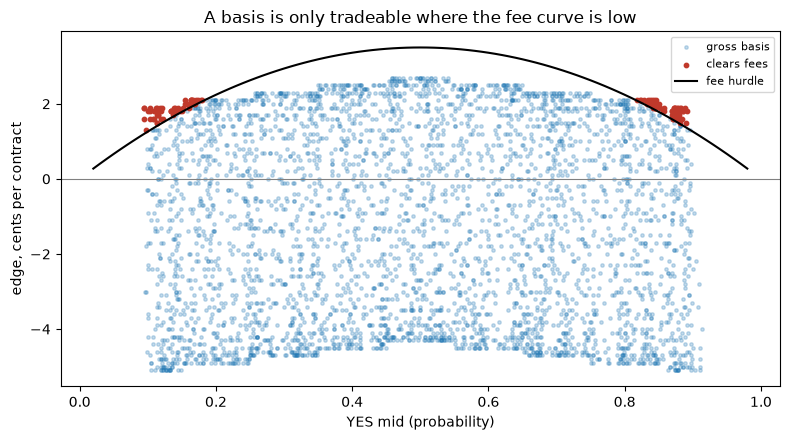

In [6]:
fig, ax = plt.subplots(figsize=(8, 4.5))
survivors = pairs[pairs.net_edge > 0]
ax.scatter(pairs.mid_yes, pairs.gross_edge * 100, s=6, alpha=0.25, label="gross basis")
ax.scatter(survivors.mid_yes, survivors.gross_edge * 100, s=10, color="#c0392b", label="clears fees")
grid = [i / 100 for i in range(2, 99)]
ax.plot(grid, [pair_fee(p) * 100 for p in grid], color="black", lw=1.5, label="fee hurdle")
ax.axhline(0.0, color="grey", lw=0.8)
ax.set_title("A basis is only tradeable where the fee curve is low")
ax.set_xlabel("YES mid (probability)")
ax.set_ylabel("edge, cents per contract")
ax.legend(loc="upper right", fontsize=8)
fig.tight_layout()

## Trade it

One pair per market, the first instant whose net edge clears the hurdle. Two
details matter more than the selection rule.

Signals are stamped one microsecond *after* the quote they were decided from.
An order timestamped exactly on a book instant may match against the previous
snapshot, because it and the snapshot share a timestamp. Submitting after the
decision quote is both deterministic and honest: you transact at a price that
was knowable when you chose to trade.

`reduce_only` is left off and both legs are market orders, so this measures the
offers as they stood. A limit at the same price would be a different study.

In [7]:
QUANTITY = 20.0
picks = (
    pairs[pairs.net_edge > 0]
    .sort_values(["instrument_id", "ts"])
    .groupby("instrument_id", as_index=False)
    .first()
)
rows = []
for pick in picks.itertuples():
    submit = pick.ts.to_pydatetime() + dt.timedelta(microseconds=1)
    for outcome in (0, 1):
        rows.append(
            {
                "ts": submit,
                "instrument_id": pick.instrument_id,
                "outcome": outcome,
                "side": "buy",
                "quantity": QUANTITY,
                "tag": f"parity-{'yes' if outcome == 0 else 'no'}",
            }
        )
signals = backtest.signal_table(rows).sort_by([("ts", "ascending")])
backtest.create_signal_table(db, "signals")
db.append("signals", signals)
print(f"{len(picks)} markets, {signals.num_rows} legs")
print(f"mean gross edge selected: {picks.gross_edge.mean() * 100:.2f} cents")

27 markets, 54 legs
mean gross edge selected: 1.83 cents


## Gross, then net

The same signals under two execution configs. Everything else is held fixed,
including the data pin, so the difference between the runs is the fee model and
nothing else.

In [8]:
def configure(run_id: str, fee_kind: str | None) -> backtest.BacktestConfig:
    execution = (
        backtest.ExecutionConfig(fee_kind=fee_kind, fee_rate=FEE_RATE)
        if fee_kind
        else backtest.ExecutionConfig()
    )
    return backtest.BacktestConfig(
        run_id=run_id,
        data=backtest.DataConfig(signals="signals", snapshot="panel-v1"),
        portfolio=backtest.PortfolioConfig(starting_cash=100_000.0),
        execution=execution,
        metadata={"study": "binary-parity"},
    )


gross = backtest.execute(db, configure("parity-gross", None))
net = backtest.execute(db, configure("parity-kalshi", "kalshi"))


def account(result: backtest.BacktestResult) -> dict[str, float]:
    """Total the run. `realized_pnl` covers closed trades only; these pairs are
    held to resolution, so the result lives in `bt_positions.settlement_pnl`."""
    positions = result.positions.to_pandas()
    summary = result.summary()
    settled = float(positions.settlement_pnl.fillna(0.0).sum())
    fees = float(summary["commissions"])
    return {"fills": summary["fills"], "settled": settled, "fees": fees, "net": settled - fees}


for label, result in (("gross", gross), ("kalshi fees", net)):
    row = account(result)
    print(
        f"{label:12} fills={row['fills']:>4}  settlement={row['settled']:>8,.2f}  "
        f"fees={row['fees']:>7,.2f}  net={row['net']:>8,.2f}"
    )

gross        fills=  54  settlement=   10.06  fees=   0.00  net=   10.06
kalshi fees  fills=  54  settlement=   10.06  fees=   9.41  net=    0.65


## Check the arithmetic

A pair bought for `c` settles at 1.00, so the gross result must be
`quantity * (1 - c)` summed over the pairs that actually filled. Reading it off
`bt_fills` rather than the intended prices tests the whole path: selection,
submission timing, matching and settlement.

In [9]:
fills = gross.fills.to_pandas()
realized_cost = fills.groupby("instrument_id").price.sum()
expected = float((QUANTITY * (1.0 - realized_cost)).sum())
positions = gross.positions.to_pandas()
booked = float(positions.settlement_pnl.sum())
print(f"pairs filled: {len(realized_cost)} of {len(picks)}")
print(f"expected from arithmetic: {expected:,.2f}")
print(f"booked as settlement:     {booked:,.2f}")
assert abs(expected - booked) < 1e-6, (expected, booked)
after_fees = account(net)
print(f"the same pairs after the real fee curve: {after_fees['net']:,.2f}")
print(f"fees consumed {after_fees['fees'] / expected:.0%} of the gross edge")

pairs filled: 27 of 27
expected from arithmetic: 10.06
booked as settlement:     10.06
the same pairs after the real fee curve: 0.65
fees consumed 94% of the gross edge


## What survives

The selection already required a positive net edge, so the net run stays
positive. Dropping that filter is the instructive counterfactual: trade every
market-instant whose gross basis is positive and the fee curve takes the whole
thing back.

In [10]:
naive = pairs[pairs.gross_edge > 0]
print(f"gross-positive opportunities: {len(naive):,}")
print(f"  mean gross edge: {naive.gross_edge.mean() * 100:+.2f} cents")
print(f"  mean net edge:   {naive.net_edge.mean() * 100:+.2f} cents")
print(f"  fraction still positive after fees: {(naive.net_edge > 0).mean():.1%}")
by_level = naive.assign(
    level=lambda f: f.mid_yes.round(1).clip(0.1, 0.9)
).groupby("level").net_edge.mean() * 100
print("\nmean net edge by price level, cents:")
print(by_level.round(2).to_string())

gross-positive opportunities: 1,474
  mean gross edge: +1.52 cents
  mean net edge:   -1.26 cents
  fraction still positive after fees: 7.3%

mean net edge by price level, cents:
level
0.1   -0.25
0.2   -0.84
0.3   -1.43
0.4   -1.72
0.5   -1.74
0.6   -1.67
0.7   -1.45
0.8   -0.79
0.9   -0.31


## Takeaways

- YES + NO = 1.00 is an identity, so a pair bought below 1.00 needs no view on
  the event. It needs a view on fees.
- The venue fee is `rate * q * p * (1-p)`, not `notional * rate`. It is
  near-zero at the tails and worst at even odds, which is where these markets
  trade most.
- Stamp signals strictly after the quote you decided from. An order sharing a
  timestamp with a book event may match the previous snapshot.
- Settlement did the accounting: `bt_positions.settlement_pnl` matched the
  `quantity * (1 - pair_cost)` arithmetic to the cent, computed from the fills
  the engine actually produced. `realized_pnl` alone reads zero here, because
  nothing was closed before resolution.
- Selecting on the hurdle leaves a thin positive net. Selecting on the gross
  basis alone loses money at every price level, and loses most at even odds.
- h5i-db features doing the work: a named snapshot pinning the panel, the
  builder join that put both outcomes on one row, and two runs over one pin
  that differ only in `fee_kind`.

In [11]:
db.close()